# K Mean for Utilities

In [364]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [365]:
df = pd.read_csv("Utilities.csv")
df.head()

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044


In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        22 non-null     object 
 1   Fixed_charge   22 non-null     float64
 2   RoR            22 non-null     float64
 3   Cost           22 non-null     int64  
 4   Load_factor    22 non-null     float64
 5   Demand_growth  22 non-null     float64
 6   Sales          22 non-null     int64  
 7   Nuclear        22 non-null     float64
 8   Fuel_Cost      22 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.7+ KB


## Visualize all feature dimensions.

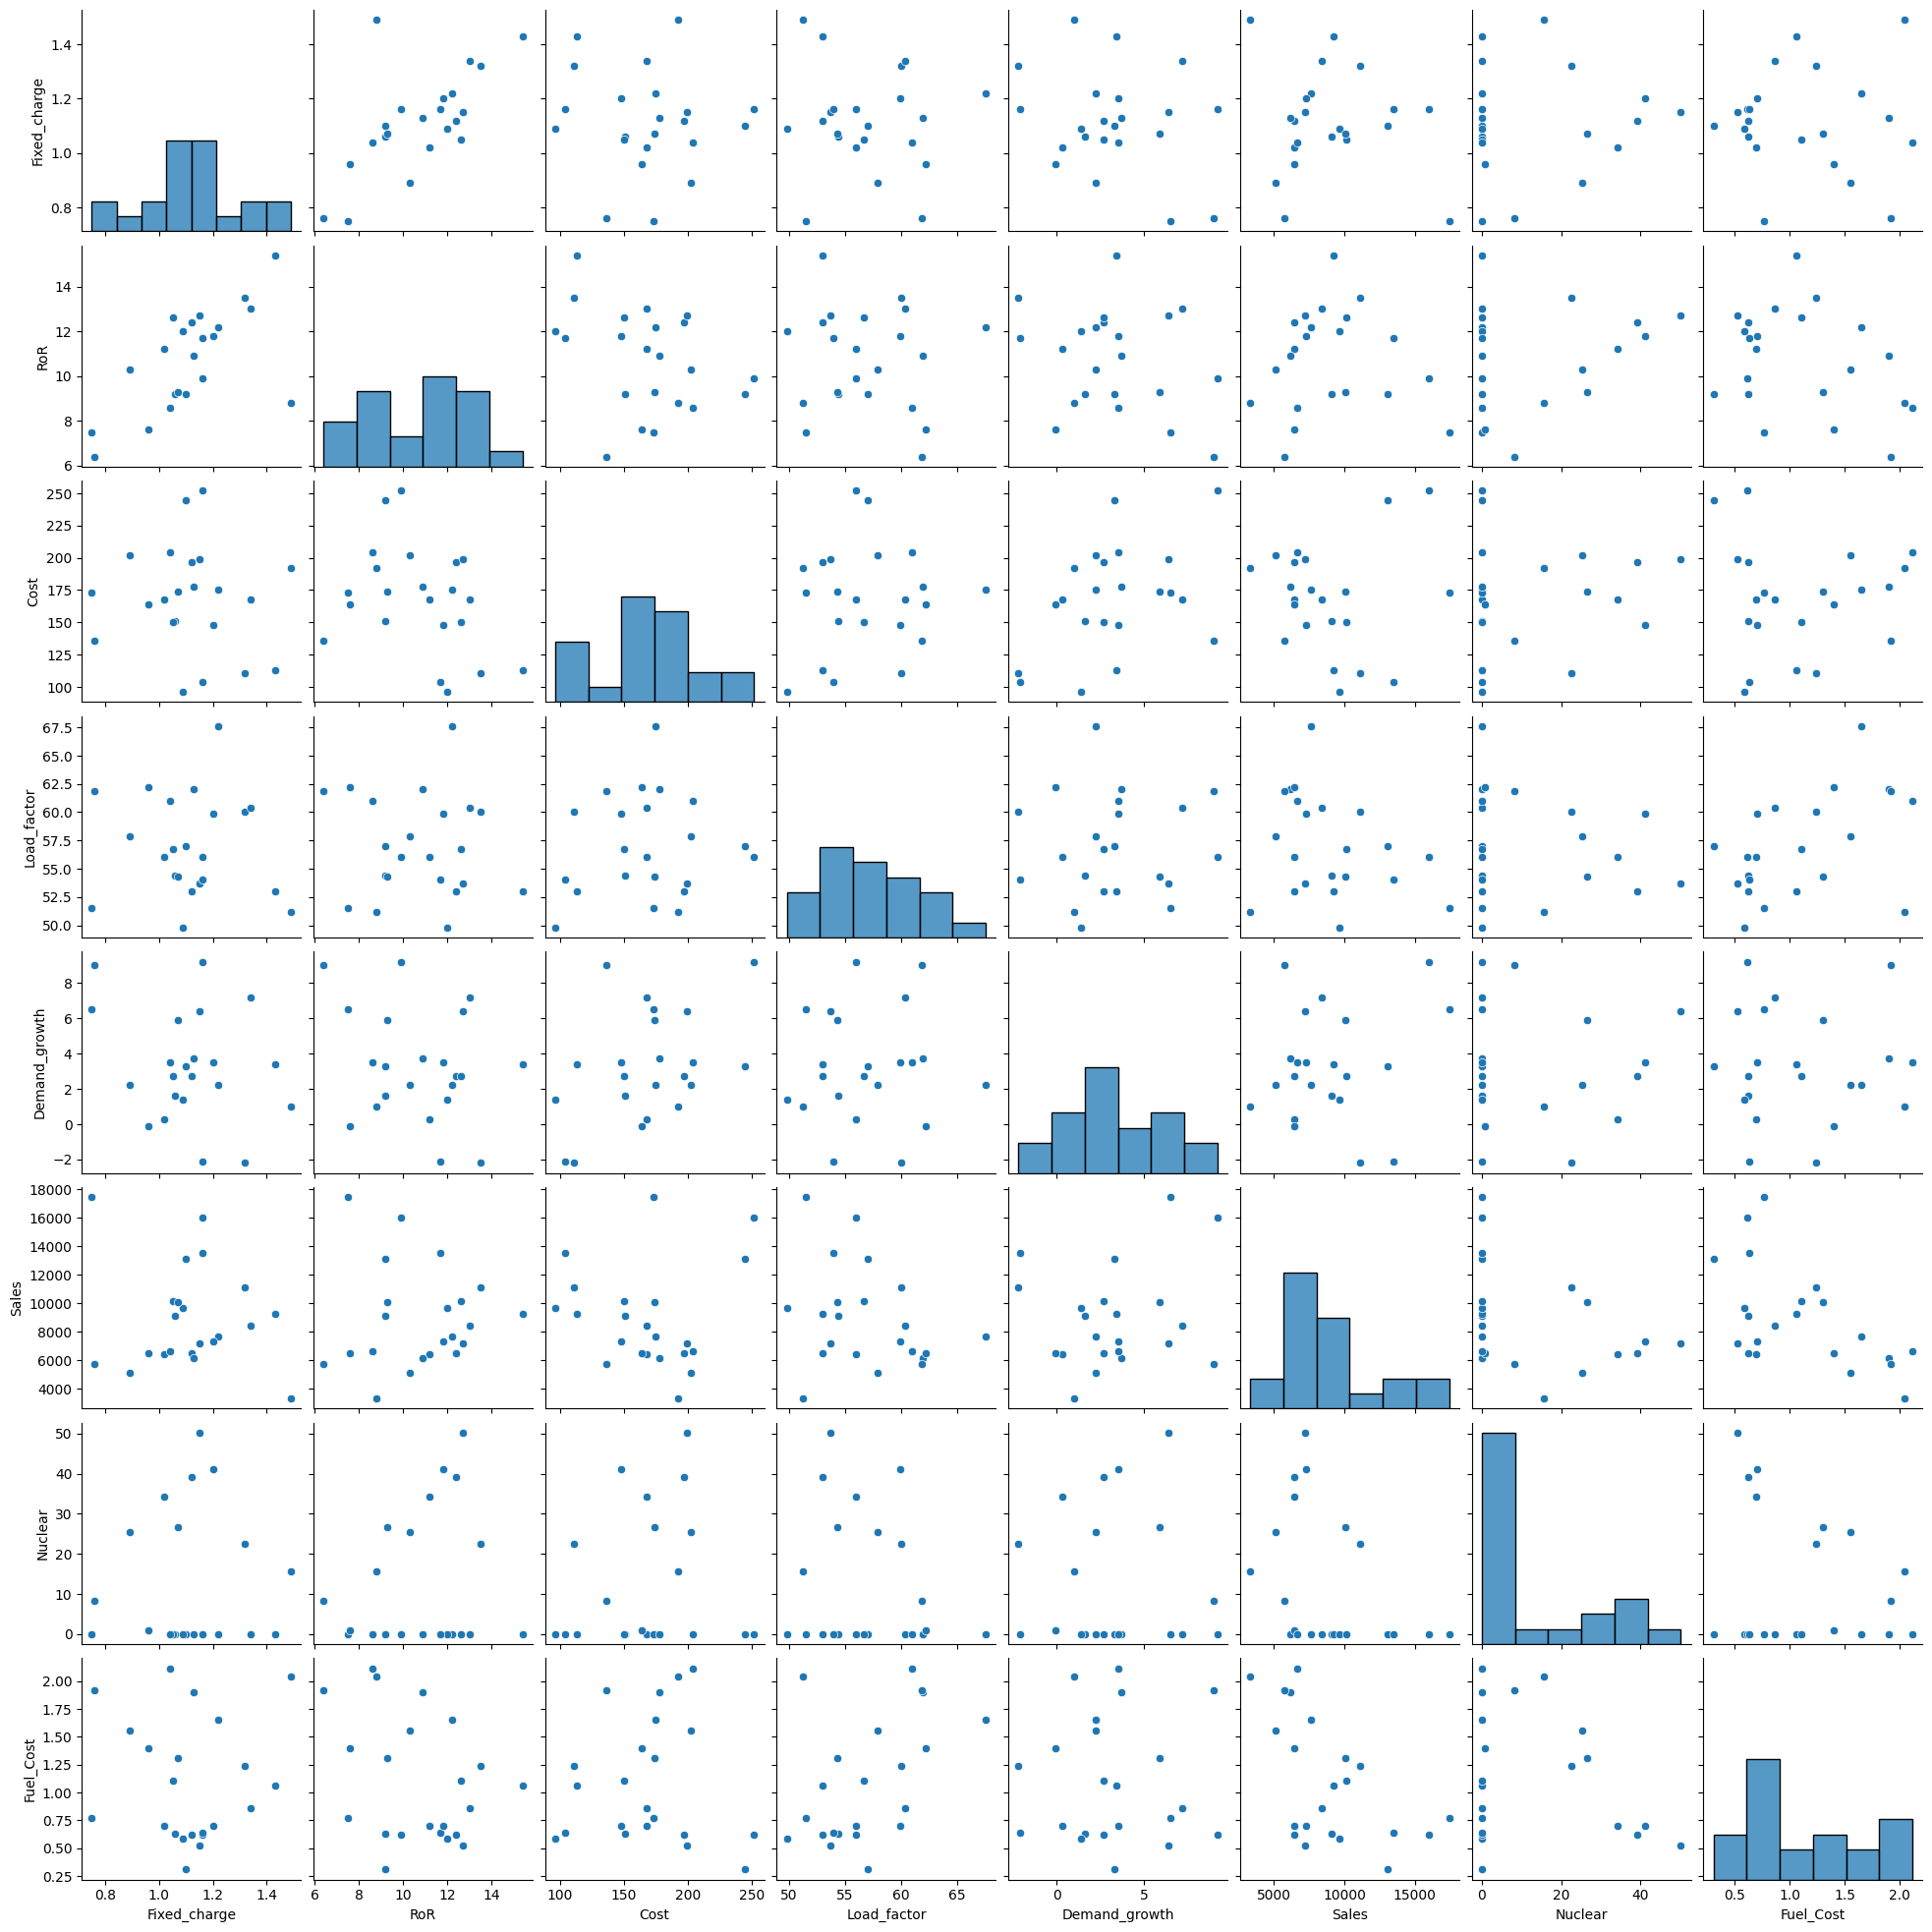

In [367]:
sns.pairplot(df.drop('Company', axis=1))
plt.show()

In [368]:
# plt.scatter(df['Fixed_charge'],df['RoR'])
# plt.xlabel('Fixed_Charge')
# plt.ylabel('RoR')

In [369]:
# km = KMeans(n_clusters=3,init = 'k-means++')
# y_predicted = km.fit_predict(df[['Fixed_charge','RoR']])
# y_predicted

In [370]:
# df['cluster']=y_predicted
# df.head()

In [371]:
# km.cluster_centers_

In [372]:
# df1 = df[df.cluster==0]
# df2 = df[df.cluster==1]
# df3 = df[df.cluster==2]
# plt.scatter(df1['Fixed_charge'],df1['RoR'],color='green')
# plt.scatter(df2['Fixed_charge'],df2['RoR'],color='red')
# plt.scatter(df3['Fixed_charge'],df3['RoR'],color='black')
# plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
# plt.xlabel('Fixed_charge')
# plt.ylabel('RoR')
# plt.legend()

## Preprocessing using min max scaler

In [373]:
scaler = MinMaxScaler()
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.drop('Company', axis=1))

In [374]:
df.head()

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044


In [375]:
# km.cluster_centers_

In [376]:
# df1 = df[df.cluster==0]
# df2 = df[df.cluster==1]
# df3 = df[df.cluster==2]
# plt.scatter(df1['Fixed_charge'],df1['RoR'],color='green')
# plt.scatter(df2['Fixed_charge'],df2['RoR'],color='red')
# plt.scatter(df3['Fixed_charge'],df3['RoR'],color='black')
# plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
# plt.xlabel('Fixed_charge')
# plt.ylabel('RoR')
# plt.legend()

## Elbow plot

In [377]:
wcss = []
k_rng = range(1,15)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df_scaled)
    wcss.append(km.inertia_)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

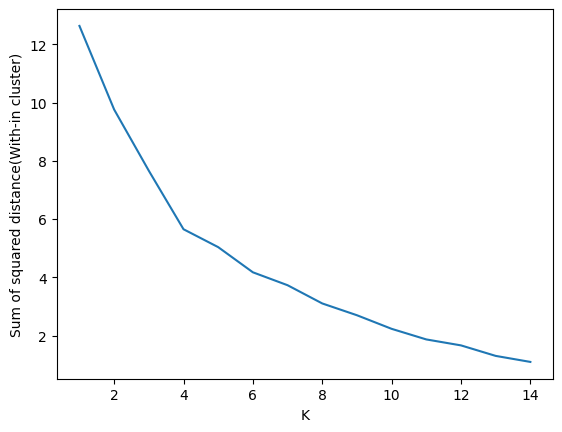

In [378]:
plt.xlabel('K')
plt.ylabel('Sum of squared distance(With-in cluster)')
plt.plot(k_rng,wcss)

**Best K is 4** with weird idea by paint and ruler!

In [379]:
# df.groupby('Cluster').describe().T

In [380]:
km = KMeans(n_clusters=4,init = 'k-means++')
y_predicted = km.fit_predict(df_scaled)
y_predicted

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([0, 1, 0, 3, 1, 0, 1, 2, 0, 3, 2, 1, 3, 0, 1, 2, 1, 0, 0, 3, 1, 3],
      dtype=int32)

In [381]:
df['Cluster'] = y_predicted

In [ ]:
sns.pairplot(df, hue='Cluster')
plt.show()

In [ ]:
df.columns

In [ ]:
cols=['Fixed_charge', 'RoR', 'Cost', 'Load_factor','Demand_growth', 'Sales', 'Nuclear', 'Fuel_Cost']
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(10, 30))
ax=ax.ravel()
for i, col in enumerate(cols):
    sns.violinplot(x='Cluster', y=col, data=df, ax=ax[i])

# nrow เกินเพื่อให้ดูว่าไม่มีอะไรหลุดมา

In [ ]:
cols=['Fixed_charge', 'RoR', 'Cost', 'Load_factor','Demand_growth', 'Sales', 'Nuclear', 'Fuel_Cost']
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(20, 30))
ax=ax.ravel()
for i, col in enumerate(cols):
    sns.boxenplot(x='Cluster', y=col, data=df, ax=ax[i])

# nrow เกินเพื่อให้ดูว่าไม่มีอะไรหลุดมา

In [ ]:
sns.countplot(x='Cluster', data=df);

In [ ]:
df.groupby('Cluster').describe().T